In [6]:
# make sure data files are loadable
import pickle
from pathlib import Path 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

DATA_PROCESSED = Path("../data/processed")

required = ["train.pkl", "test.pkl", "train_demographics.pkl", "test_demographics.pkl"]
for fn in required:
    p = DATA_PROCESSED / fn
    print(fn, "exists:", p.exists(), "size_MB:", round(p.stat().st_size/1024/1024,1) if p.exists() else None)

def load_pkl(name):
    with open(DATA_PROCESSED / name, "rb") as f:
        return pickle.load(f)
    
train_df = load_pkl("train.pkl")
test_df = load_pkl("test.pkl")
train_demo_df = load_pkl("train_demographics.pkl")
test_demo_df = load_pkl("test_demographics.pkl")

print("train_df:", train_df.shape)
print("test_df:", test_df.shape)
print("train_demo_df:", train_demo_df.shape)
print("test_demo_df:", test_demo_df.shape)

Matplotlib is building the font cache; this may take a moment.


train.pkl exists: True size_MB: 1491.1
test.pkl exists: True size_MB: 0.3
train_demographics.pkl exists: True size_MB: 0.0
test_demographics.pkl exists: True size_MB: 0.0
train_df: (574945, 341)
test_df: (107, 336)
train_demo_df: (81, 8)
test_demo_df: (2, 8)


In [8]:
# find label like columns
id_like = ["row_id","sequence_type","sequence_id","sequence_counter","subject"]
cat_cols = [c for c in train_df.columns if train_df[c].dtype == "object" and c not in id_like]

summary = []
for c in cat_cols:
    summary.append((c, train_df[c].nunique(dropna=False), train_df[c].isna().mean()))
summary = pd.DataFrame(summary, columns=["col","n_unique","na_rate"]).sort_values("n_unique")

summary

,col,n_unique,na_rate


num classes: 18


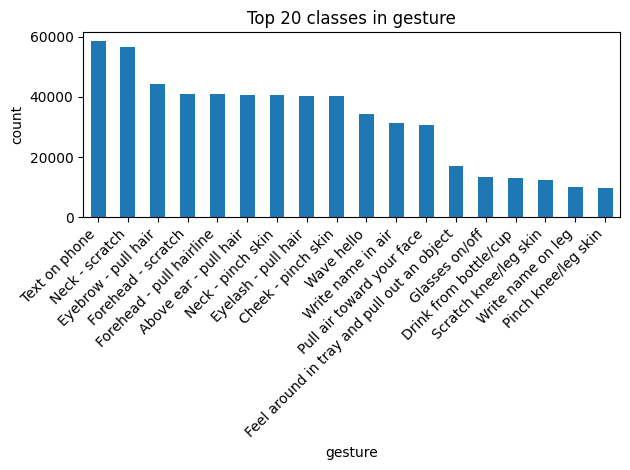

In [10]:
label_col = "gesture"

vc = train_df[label_col].value_counts(dropna=False)
print("num classes:", vc.shape[0])
vc.head(20)

# draw the top 20s 
plt.figure()
vc.head(20).plot(kind="bar")
plt.title(f"Top 20 classes in {label_col}")
plt.xlabel(label_col)
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

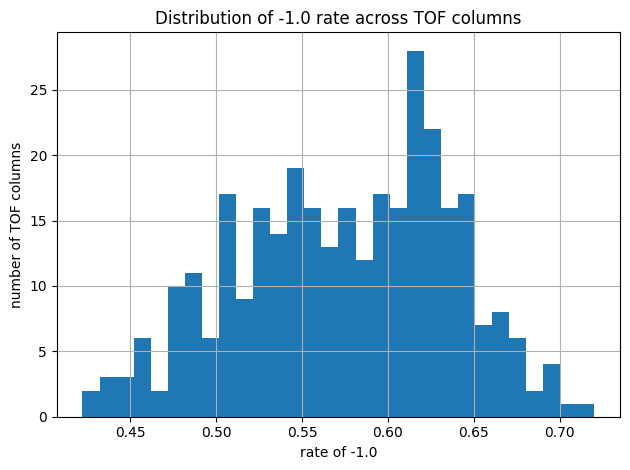

In [11]:
num_cols = train_df.select_dtypes(include=[np.number]).columns
neg1_rate = (train_df[num_cols] == -1.0).mean().sort_values(ascending=False)

neg1_rate.head(20)

tof_cols = [c for c in train_df.columns if c.lower().startswith("tof_")]
tof_neg1 = (train_df[tof_cols] == -1.0).mean().sort_values(ascending=False)

plt.figure()
tof_neg1.hist(bins=30)
plt.title("Distribution of -1.0 rate across TOF columns")
plt.xlabel("rate of -1.0")
plt.ylabel("number of TOF columns")
plt.tight_layout()
plt.show()

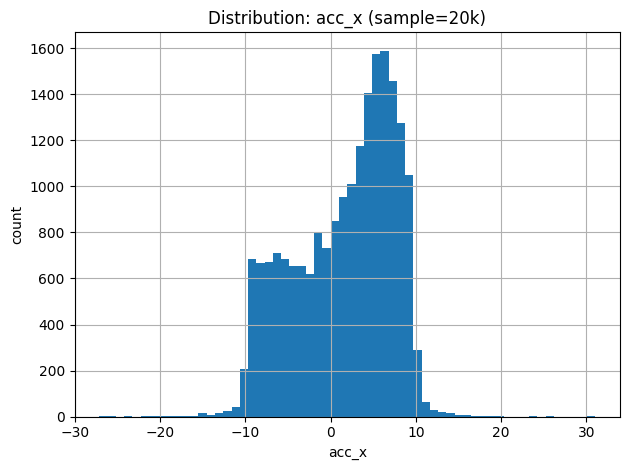

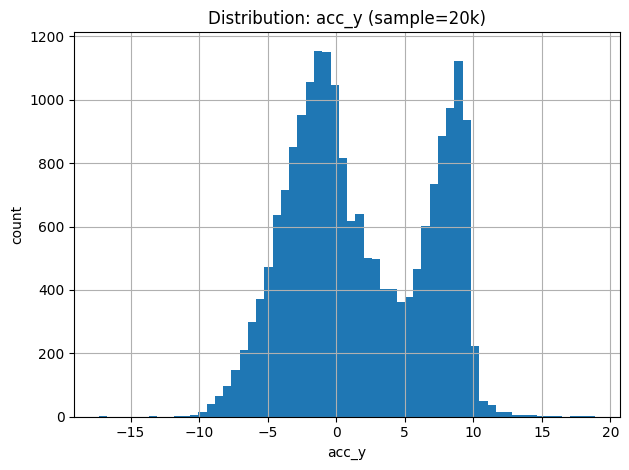

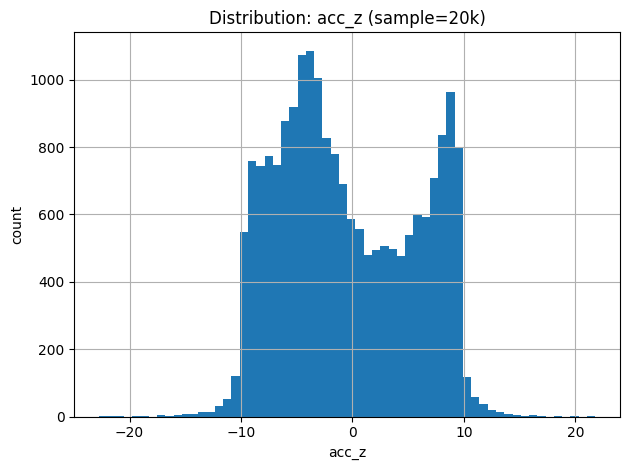

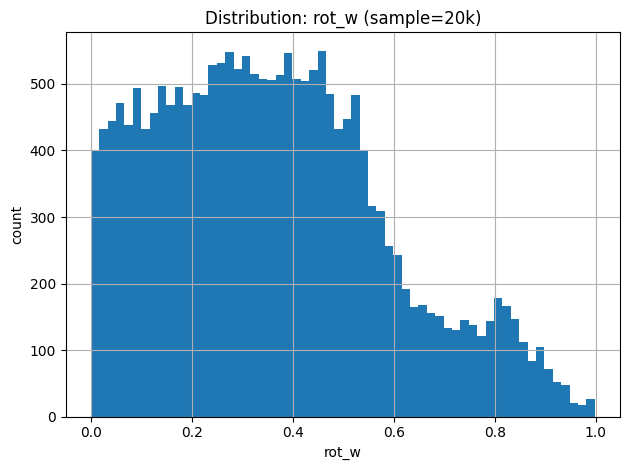

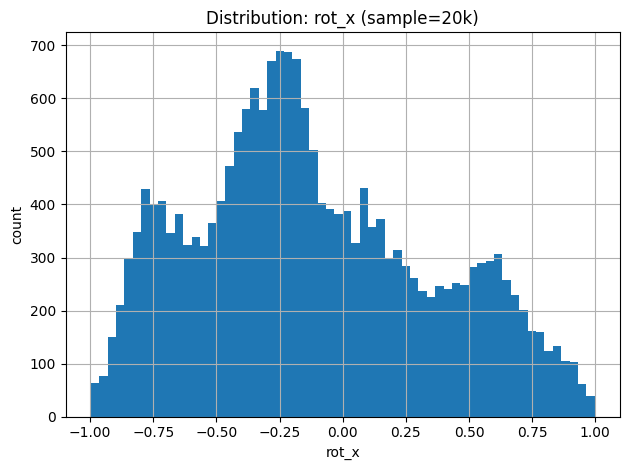

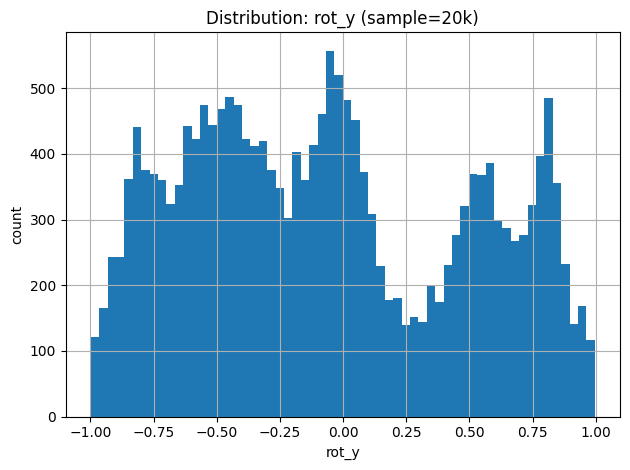

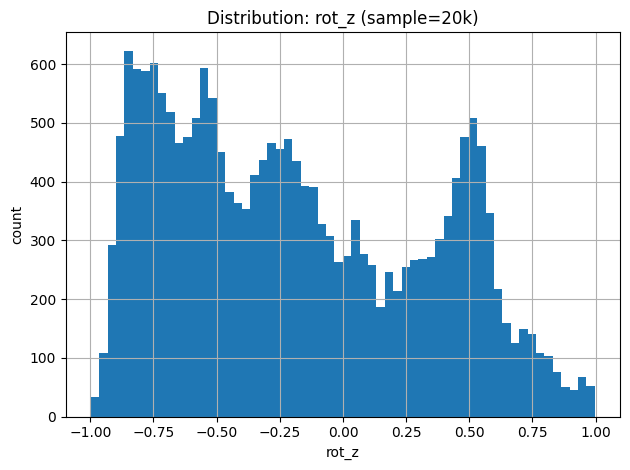

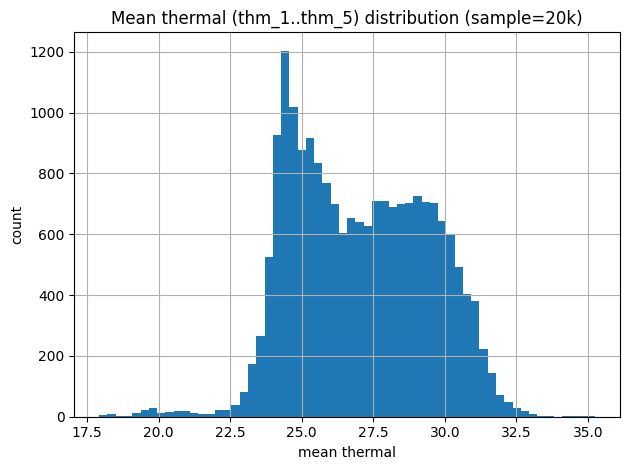

In [12]:
# IMU/rotation/thermal distribution
sample = train_df.sample(n=20000, random_state=42)
for c in ["acc_x","acc_y","acc_z","rot_w","rot_x","rot_y","rot_z"]:
    if c in sample.columns:
        plt.figure()
        sample[c].hist(bins=60)
        plt.title(f"Distribution: {c} (sample=20k)")
        plt.xlabel(c)
        plt.ylabel("count")
        plt.tight_layout()
        plt.show()

thm_cols = [c for c in train_df.columns if c.startswith("thm_")]
sample_thm = train_df[thm_cols].sample(n=20000, random_state=42)

plt.figure()
sample_thm.mean(axis=1).hist(bins=60)
plt.title("Mean thermal (thm_1..thm_5) distribution (sample=20k)")
plt.xlabel("mean thermal")
plt.ylabel("count")
plt.tight_layout()
plt.show()

subjects: 81 classes: 18


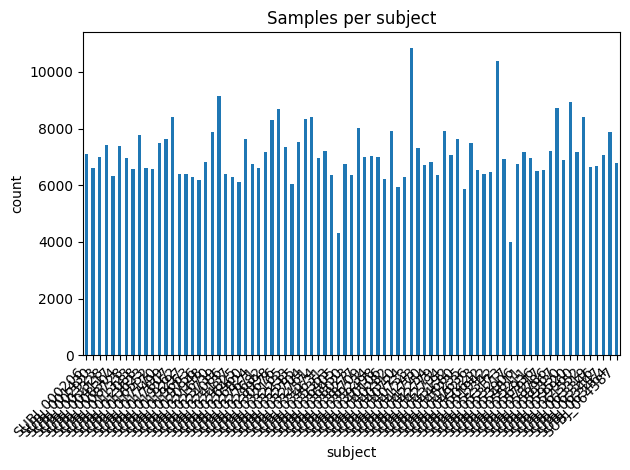

In [13]:
# base on subject see the distribution of label
ct = pd.crosstab(train_df["subject"], train_df[label_col])
print("subjects:", ct.shape[0], "classes:", ct.shape[1])
ct.sum(axis=1).sort_values(ascending=False).head(10)

plt.figure()
ct.sum(axis=1).plot(kind="bar")
plt.title("Samples per subject")
plt.xlabel("subject")
plt.ylabel("count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

sequence_id: SEQ_000007 len: 57


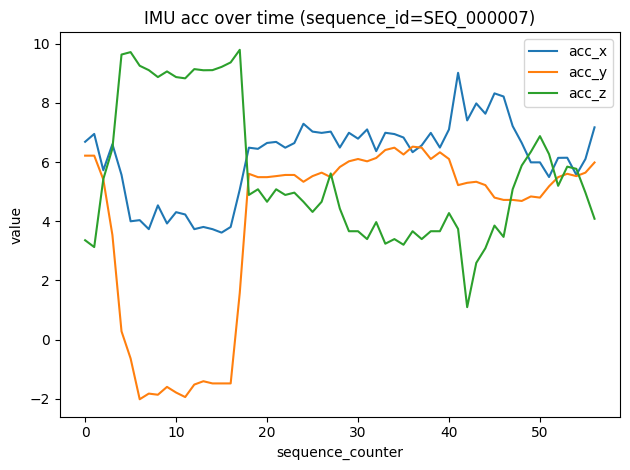

In [14]:
# sequence time sequence
one_seq = train_df["sequence_id"].iloc[0]
seq_df = train_df[train_df["sequence_id"] == one_seq].sort_values("sequence_counter")

print("sequence_id:", one_seq, "len:", len(seq_df))
seq_df[[label_col, "sequence_counter"]].head()

#acc_x/acc_y/acc_z
plt.figure()
plt.plot(seq_df["sequence_counter"], seq_df["acc_x"], label="acc_x")
plt.plot(seq_df["sequence_counter"], seq_df["acc_y"], label="acc_y")
plt.plot(seq_df["sequence_counter"], seq_df["acc_z"], label="acc_z")
plt.title(f"IMU acc over time (sequence_id={one_seq})")
plt.xlabel("sequence_counter")
plt.ylabel("value")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# train vs test column mismatch check

train_cols = list(train_df.columns)
test_cols = list(test_df.columns)

train_set = set(train_cols)
test_set = set(test_cols)

only_in_train = sorted(train_set - test_set)
only_in_test = sorted(test_set - train_set)

print("train cols:", len(train_cols))
print("test cols:", len(test_cols))
print("\nOnly in TRAIN (missing in test):", len(only_in_train))
print(only_in_train)

print("\nOnly in TEST (missing in train):", len(only_in_test))
print(only_in_test)

# guess: label columns are often only in train
possible_label_like = [c for c in only_in_train if any(k in c.lower() for k in ["label","target","gesture","class","y"])]
print("\nPossible label-like cols (train only):", possible_label_like)
